In [7]:
import pandas as pd

df_main = pd.read_csv("detections.csv")        # person + racket
df_ball = pd.read_csv("ball_detections.csv")   # ball

# --- Fix column name mismatch ---
df_ball = df_ball.rename(columns={"conf": "confidence"})

# --- Ensure expected columns exist in main ---
cols_main = ["frame", "track_id", "label", "x1", "y1", "x2", "y2", "confidence"]
df_main = df_main[cols_main]

# --- Build ball dataframe in same schema ---
df_ball = df_ball[["frame", "x1", "y1", "x2", "y2", "confidence"]].copy()

# Add missing columns for compatibility
df_ball["track_id"] = -1          # or any sentinel value
df_ball["label"] = "ball"

# --- OPTIONAL: make track IDs unique ---
df_ball["track_id"] = df_ball["track_id"]+1000  # avoids clashes

# --- tag source ---
df_main["source"] = "main"
df_ball["source"] = "ball"

# Merge
df_all = pd.concat([df_main, df_ball], ignore_index=True)

# Sort
df_all = df_all.sort_values(["frame"]).reset_index(drop=True)

# --- center coordinates ---
df_all["cx"] = (df_all["x1"] + df_all["x2"]) / 2
df_all["cy"] = (df_all["y1"] + df_all["y2"]) / 2

df_all["cx"] = df_all["cx"].round(2)
df_all["cy"] = df_all["cy"].round(2)

df_all.to_csv("combined_detections.csv", index=False)

print("Saved → combined_detections.csv")

Saved → combined_detections.csv


In [ ]:
import cv2
import pandas as pd

df = pd.read_csv("combined_detections.csv")

colors = {
    "person": (0, 255, 0),
    "racket": (255, 0, 0),
    "ball": (0, 0, 255)
}

frame_group = df.groupby("frame")

cap = cv2.VideoCapture("input.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in frame_group.groups:
        for _, row in frame_group.get_group(frame_idx).iterrows():
            x1, y1, x2, y2 = map(int, [row.x1, row.y1, row.x2, row.y2])
            label = row.label

            color = colors.get(label, (255, 255, 255))

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame,
                        f"{label} {row.track_id}",
                        (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        color,
                        1)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

print("Done → output.mp4")

Done → output.mp4


In [8]:
MINIMUM_DISTANCE_THRESHOLD = 120  # pixels
# plot racket-ball distance over time
import numpy as np
import pandas as pd

def compute_windowed_racket_ball_distance(df, window):

    results = []
    frames = sorted(df["frame"].unique())

    for frame in frames:

        # collect nearby frames
        window_df = df[
            (df["frame"] >= frame - window) &
            (df["frame"] <= frame + window)
        ]

        balls = window_df[window_df["label"] == "ball"]
        rackets = window_df[window_df["label"] == "racket"]

        if len(balls) == 0 or len(rackets) == 0:
            continue

        min_dist = float(MINIMUM_DISTANCE_THRESHOLD)

        closest_racket_id = None
        closest_ball_id = None

        for _, b in balls.iterrows():

            bx, by = b["cx"], b["cy"]

            for _, r in rackets.iterrows():

                dist = np.sqrt(
                    (r["cx"] - bx)**2 +
                    (r["cy"] - by)**2
                )

                if dist < min_dist:
                    min_dist = dist
                    closest_racket_id = r["track_id"]
                    closest_ball_id = b["track_id"]

        if min_dist <= MINIMUM_DISTANCE_THRESHOLD:

            results.append({
                "frame": frame,
                "racket_id": closest_racket_id,
                "ball_id": closest_ball_id,
                "distance": min_dist
            })

    return pd.DataFrame(results)

In [9]:
df_dist = compute_windowed_racket_ball_distance(df_all, window=5)
print(df_dist)

      frame  racket_id  ball_id  distance
0         0        NaN      NaN     120.0
1         1        NaN      NaN     120.0
2         2        NaN      NaN     120.0
3         3        NaN      NaN     120.0
4         4        NaN      NaN     120.0
...     ...        ...      ...       ...
7989   8120        NaN      NaN     120.0
7990   8121        NaN      NaN     120.0
7991   8122        NaN      NaN     120.0
7992   8123        NaN      NaN     120.0
7993   8124        NaN      NaN     120.0

[7994 rows x 4 columns]


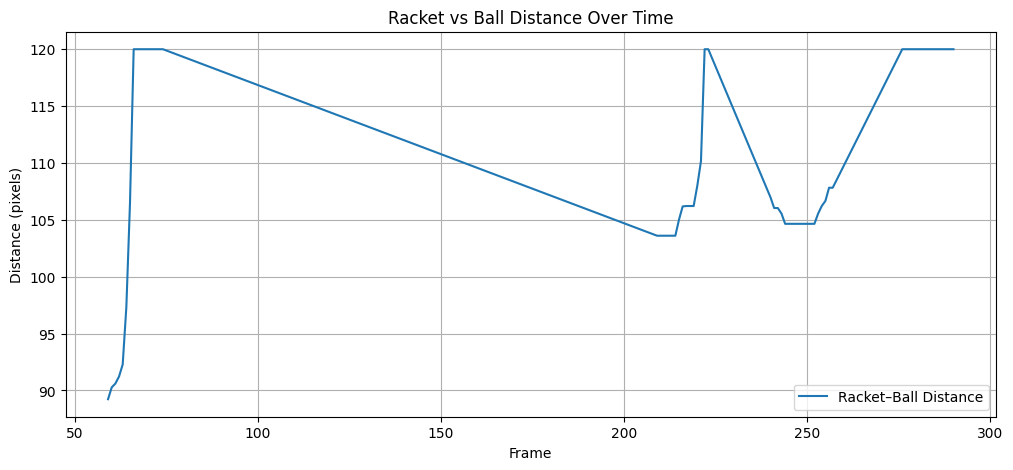

In [202]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_dist["frame"], df_dist["distance"], label="Racket–Ball Distance")

plt.xlabel("Frame")
plt.ylabel("Distance (pixels)")
plt.title("Racket vs Ball Distance Over Time")
plt.legend()
plt.grid()

plt.show()

In [203]:
import numpy as np
from scipy.signal import argrelextrema

# 1. Identify the indices of the dips
# order=15 ensures we find the major 'hits' and ignore small tracking jitters
dip_indices = argrelextrema(df_dist['distance'].values, np.less_equal, order=3)[0]

# 2. Extract the actual frames and distances
local_minima = df_dist.iloc[dip_indices].copy()

# 3. Clean up: If a dip is a plateau (multiple frames with same value), 
# keep only the middle frame of that hit.
local_minima = local_minima.groupby('distance').head(1)
local_minima

,frame,racket_id,ball_id,distance
0,59,57.0,10016.0,89.232841
10,69,NaN,NaN,120.000000
16,209,261.0,10051.0,103.606226
35,244,290.0,10083.0,104.651804


In [204]:
distance_threshold = 110
racket_hits = local_minima[local_minima["distance"] < distance_threshold]
print(racket_hits)

    frame  racket_id  ball_id    distance
0      59       57.0  10016.0   89.232841
16    209      261.0  10051.0  103.606226
35    244      290.0  10083.0  104.651804


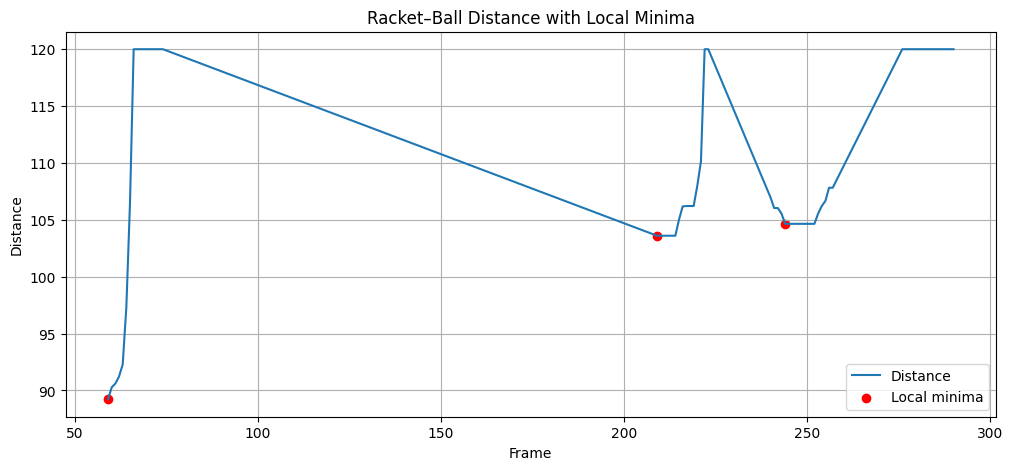

In [205]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_dist["frame"], df_dist["distance"], label="Distance")

plt.scatter(
    racket_hits["frame"],
    racket_hits["distance"],
    color="red",
    label="Local minima"
)

plt.xlabel("Frame")
plt.ylabel("Distance")
plt.title("Racket–Ball Distance with Local Minima")
plt.legend()
plt.grid()
plt.show()

In [206]:
import numpy as np

def dist(a, b):
    return np.sqrt((a["cx"] - b["cx"])**2 + (a["cy"] - b["cy"])**2)

In [207]:
# Expand hit frames by ±3
expanded_frames = set()

# racket-ball hit bhayeko frame ko suruma 3 frame pachi samma ra suruma 3 frame aghi samma lai include garne
for f in hit_frames:
    for offset in range(-3, 4):   # -3 to +3 inclusive
        expanded_frames.add(f + offset)

# Filter dataframe
df_players_rackets_hits = df_all[
    (df_all["frame"].isin(expanded_frames)) &
    (df_all["label"].isin(["person", "racket"]))
].copy()

print(df_players_rackets_hits)

      frame  track_id   label    x1   y1    x2   y2  confidence source  \
658      56         1  person   750  670   836  794    0.334726   main   
659      56         2  person   840   47   877  126    0.841258   main   
660      56         3  person   694  277   770  429    0.902286   main   
661      56         4  person  1079   55  1130  125    0.848440   main   
662      56         5  person  1031    0  1062   45    0.751572   main   
...     ...       ...     ...   ...  ...   ...  ...         ...    ...   
2876    247       183  person    64  423   109  476    0.403377   main   
2877    247       187  person   997    0  1027   40    0.753987   main   
2878    247       188  person  1136   62  1179  126    0.651934   main   
2879    247       260  person   848  518  1001  720    0.915392   main   
2880    247       290  racket   774  328   803  357    0.595752   main   

          cx     cy  
658    793.0  732.0  
659    858.5   86.5  
660    732.0  353.0  
661   1104.5   90.0  
6

In [208]:
import numpy as np
import pandas as pd

results = []

for frame in df_players_rackets_hits["frame"].unique():

    frame_df = df_players_rackets_hits[
        df_players_rackets_hits["frame"] == frame
    ]

    # racket + ball ids for this frame
    racket_hit_row = racket_hits[
        racket_hits["frame"] == frame
    ]

    if racket_hit_row.empty:
        continue

    racket_id = racket_hit_row.iloc[0]["racket_id"]
    ball_id = racket_hit_row.iloc[0]["ball_id"]

    # select ONLY that racket
    racket = frame_df[
        (frame_df["label"] == "racket") &
        (frame_df["track_id"] == racket_id)
    ]

    players = frame_df[
        frame_df["label"] == "person"
    ]

    if racket.empty or players.empty:
        continue

    rx, ry = racket.iloc[0]["cx"], racket.iloc[0]["cy"]

    for _, p in players.iterrows():

        dist = np.sqrt(
            (rx - p["cx"])**2 +
            (ry - p["cy"])**2
        )

        results.append({
            "frame": frame,
            "racket_id": racket_id,
            "ball_id": ball_id,
            "player_id": p["track_id"],
            "distance": dist
        })

df_dist_person_racket = pd.DataFrame(results)

print(df_dist_person_racket)

    frame  racket_id  ball_id  player_id    distance
0      59       57.0  10016.0          1   55.400812
1      59       57.0  10016.0          2  686.053205
2      59       57.0  10016.0          3  428.439027
3      59       57.0  10016.0          4  736.861588
4      59       57.0  10016.0          5  779.523572
5      59       57.0  10016.0          6  751.815137
6      59       57.0  10016.0         11  876.346535
7      59       57.0  10016.0         15  842.765092
8      59       57.0  10016.0         52  794.913360
9      59       57.0  10016.0         58   51.000000
10    209      261.0  10051.0          2  679.009021
11    209      261.0  10051.0          3  429.214399
12    209      261.0  10051.0          6  718.661429
13    209      261.0  10051.0          8  744.422091
14    209      261.0  10051.0         11  868.586208
15    209      261.0  10051.0         12  731.527341
16    209      261.0  10051.0         58   82.840208
17    209      261.0  10051.0        183  800.

In [209]:
# map: (frame, closest_player)
frame_player_map = df_dist_person_racket.groupby("frame").apply(
    lambda x: x.loc[x["distance"].idxmin(), "player_id"]
).to_dict()
frame_player_map

C:\Users\Admin\AppData\Local\Temp\ipykernel_13900\1320283732.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  frame_player_map = df_dist_person_racket.groupby("frame").apply(


{59: 58, 209: 260, 244: 3}

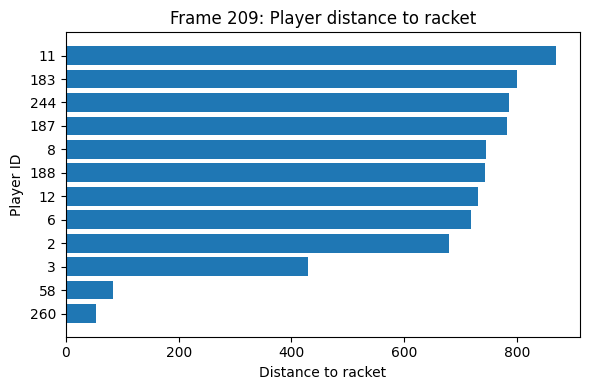

In [210]:
import matplotlib.pyplot as plt

frame_id = 209
df_f = df_dist_person_racket[df_dist_person_racket["frame"] == frame_id] \
        .sort_values("distance")

plt.figure(figsize=(6,4))
plt.barh(df_f["player_id"].astype(str), df_f["distance"])
plt.xlabel("Distance to racket")
plt.ylabel("Player ID")
plt.title(f"Frame {frame_id}: Player distance to racket")
plt.tight_layout()
plt.show()

In [211]:

df_main = pd.read_csv("combined_detections.csv")
filtered_rows = []

for _, row in df_dist_person_racket.iterrows():

    frame = row["frame"]
    racket_id = row["racket_id"]

    # ONLY use closest player for this frame
    player_id = frame_player_map[frame]

    keep = df_main[
        (df_main["frame"] == frame) &
        (
            ((df_main["label"] == "person") & (df_main["track_id"] == player_id)) |
            ((df_main["label"] == "racket") & (df_main["track_id"] == racket_id)) |
            (df_main["label"] == "ball")
        )
    ]

    filtered_rows.append(keep)

df_filtered = pd.concat(filtered_rows, ignore_index=True)

# optional: remove duplicates
df_filtered = df_filtered.drop_duplicates()

df_filtered

,frame,track_id,label,x1,y1,x2,y2,confidence,source,cx,cy
0,59,57,racket,805,751,848,791,0.518534,main,826.5,771.0
1,59,58,person,725,683,838,907,0.538032,main,781.5,795.0
20,209,260,person,718,620,830,869,0.446983,main,774.0,744.5
21,209,261,racket,802,760,832,793,0.406699,main,817.0,776.5
44,244,3,person,722,279,802,442,0.917924,main,762.0,360.5
45,244,290,racket,770,319,797,346,0.676943,main,783.5,332.5


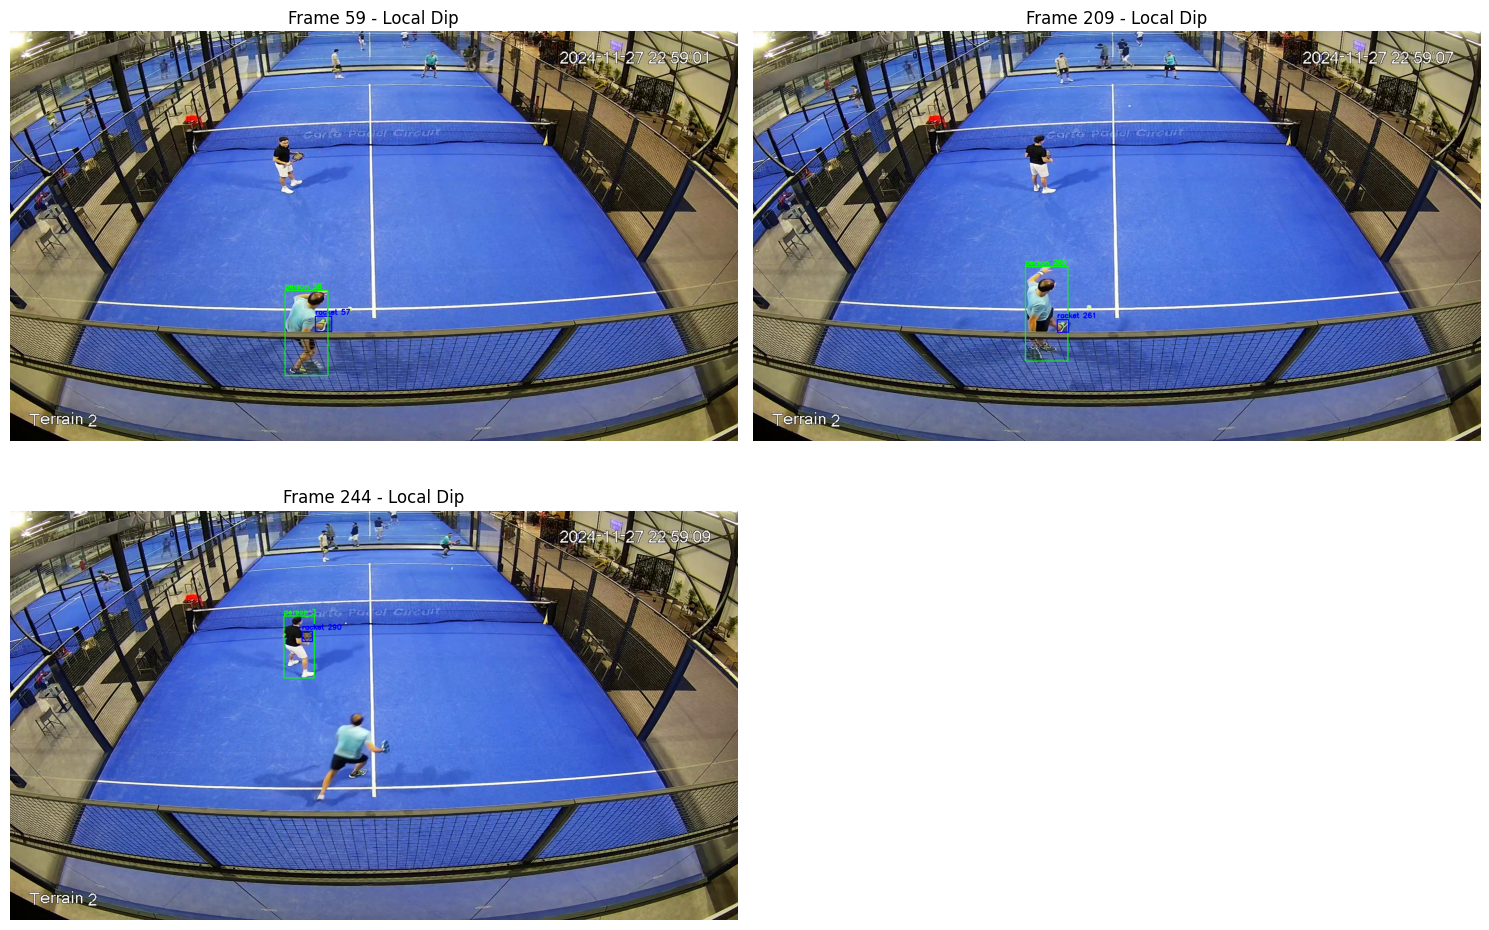

In [212]:
cap = cv2.VideoCapture("input.mp4")

frame_idx = 0
results = {}

colors = {
    "person": (0, 255, 0),
    "racket": (255, 0, 0),
    "ball": (0, 0, 255)
}

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx in df_filtered["frame"].values:

        group = df_filtered[df_filtered["frame"] == frame_idx]

        for _, row in group.iterrows():

            x1, y1, x2, y2 = map(int, [row.x1, row.y1, row.x2, row.y2])
            color = colors[row.label]

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            cv2.putText(
                frame,
                f"{row.label} {row.track_id}",
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

        results[frame_idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame_idx += 1

cap.release()


import math
# 1. Get the list of frames you want to show
frames_to_show = df_filtered["frame"].unique()
num_frames = len(frames_to_show)

# 2. Calculate grid size (e.g., if 6 frames, do 2 rows of 3)
cols = 2
rows = math.ceil(num_frames / cols)

# 3. Create the figure
plt.figure(figsize=(15, 5 * rows))

for i, f in enumerate(frames_to_show):
    # If the frame was actually captured in your results dictionary
    if f in results:
        plt.subplot(rows, cols, i + 1)
        plt.imshow(results[f])
        plt.title(f"Frame {f} - Local Dip")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [213]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 0 to 45
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   frame       6 non-null      int64  
 1   track_id    6 non-null      int64  
 2   label       6 non-null      object 
 3   x1          6 non-null      int64  
 4   y1          6 non-null      int64  
 5   x2          6 non-null      int64  
 6   y2          6 non-null      int64  
 7   confidence  6 non-null      float64
 8   source      6 non-null      object 
 9   cx          6 non-null      float64
 10  cy          6 non-null      float64
dtypes: float64(3), int64(6), object(2)
memory usage: 576.0+ bytes


In [214]:
results = []

x_thresh = 30
y_thresh = 30

for frame, group in df_filtered.groupby("frame"):

    person = group[group["label"] == "person"].iloc[0]
    racket = group[group["label"] == "racket"].iloc[0]

    cx_p, cy_p = person["cx"], person["cy"]
    cx_r, cy_r = racket["cx"], racket["cy"]

    dx = cx_r - cx_p
    dy = cy_r - cy_p

    # annotation- levl threshold filter
    if abs(dx) < x_thresh and abs(dy) < y_thresh:
        shot = "neutral"
    else:
        if cy_r < cy_p - y_thresh:
            shot = "serve"
        elif dx > x_thresh:
            shot = "forward shot"
        elif dx < -x_thresh:
            shot = "back shot"
        else:
            shot = "neutral"

    temp = group.copy()
    temp["result"] = shot
    temp["distance_pr"] = np.sqrt(dx**2 + dy**2)

    results.append(temp)

df_out = pd.concat(results, ignore_index=True)

# drop racket rows
df_out = df_out[df_out["label"] != "racket"].copy()

df_out = df_out[["frame", "track_id", "label", "result", "distance_pr"]]

df_out.to_csv("output_with_shot.csv", index=False)

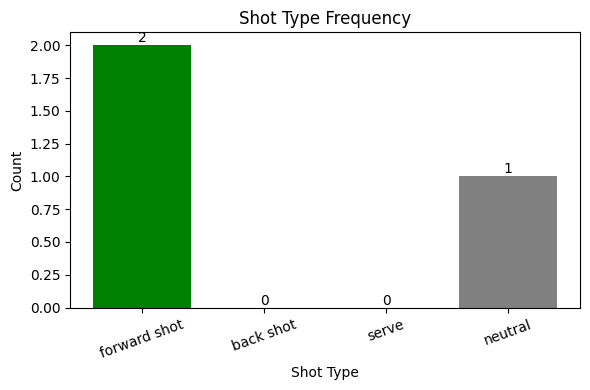

In [220]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("output_with_shot.csv")

all_shots = ["forward shot", "back shot", "serve", "neutral"]

counts = df["result"].value_counts().reindex(all_shots, fill_value=0)

colors = {
    "forward shot": "green",
    "back shot": "red",
    "serve": "blue",
    "neutral": "gray"
}

plt.figure(figsize=(6,4))

bars = plt.bar(
    counts.index,
    counts.values,
    color=[colors[k] for k in counts.index]
)

# add count labels
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        str(int(y)),
        ha='center',
        va='bottom'
    )

plt.title("Shot Type Frequency")
plt.xlabel("Shot Type")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [227]:
import cv2
import pandas as pd

df_det = pd.read_csv("combined_detections.csv")
df_events = pd.read_csv("output_with_shot.csv")

cap = cv2.VideoCapture("input.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "final_output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# -------------------------
# EVENT WINDOWS (DISPLAY)
# -------------------------
event_windows = []
event_map = {}

for _, row in df_events.iterrows():
    frame = int(row["frame"])
    result = str(row["result"]).lower()

    # exact frame event (for counting)
    event_map[frame] = result

    # time window (for display persistence)
    start = frame - int(0.2 * fps)
    end = frame + int(1.8 * fps)

    event_windows.append((start, end, result))

# -------------------------
# COUNTERS
# -------------------------
counter = {
    "forward shot": 0,
    "back shot": 0,
    "serve": 0,
    "neutral": 0
}

# -------------------------
# COLORS
# -------------------------
colors = {
    "person": (0, 255, 0),
    "racket": (255, 0, 0),
    "ball": (0, 0, 255)
}

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # -------------------------
    # DETECTIONS
    # -------------------------
    frame_df = df_det[df_det["frame"] == frame_idx]

    for _, row in frame_df.iterrows():
        x1, y1, x2, y2 = map(int, [row.x1, row.y1, row.x2, row.y2])
        label = row.label

        color = colors.get(label, (255, 255, 255))

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        cv2.putText(
            frame,
            f"{label} {row.track_id}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1
        )

    # -------------------------
    # EVENT COUNTING (EXACT FRAME)
    # -------------------------
    if frame_idx in event_map:
        event = event_map[frame_idx]

        if event in counter:
            counter[event] += 1

    # -------------------------
    # SCOREBOARD (TOP)
    # -------------------------
    base_y = 60

    scoreboard = [
        f"Forward: {counter['forward shot']}",
        f"Backward: {counter['back shot']}",
        f"Serve/Smash: {counter['serve']}",
        f"Neutral: {counter['neutral']}"
    ]

    # background box for readability
    cv2.rectangle(frame, (20, 10), (420, 180), (0, 0, 0), -1)

    for i, text in enumerate(scoreboard):
        cv2.putText(
            frame,
            text,
            (40, base_y + i * 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

    # -------------------------
    # EVENT LABEL (BELOW SCOREBOARD)
    # -------------------------
    event_y = base_y + len(scoreboard) * 30 + 70

    for start, end, result in event_windows:
        if start <= frame_idx <= end:

            cv2.putText(
                frame,
                result.upper(),
                (40, event_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                2,
                (0, 0, 255),
                3,
                cv2.LINE_AA
            )
            break

    # -------------------------
    # WRITE FRAME
    # -------------------------
    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

print("Done → final_output.mp4")

Done → final_output.mp4
